# Total Deaths and Median Age of Death by Neighborhood

This dataset contains the deaths and median age at death for all the neighborhoods in Pittsburgh over the years 2011-2015. The deaths are of individuals with residences in the neighborhood. While the data isn't as current, being from the 2010s, which are now over a decade ago, we think that it still serves as a good indicator to compare the neighborhoods with. The dataset also contains breakdowns by certain races, but this won't be considered for the purposes of the metric.

The submetric we will be using is an unweighted combination of the neighborhood rankings in both the total deaths and median age at death. Essentially, the placement of each neighborhood is its score for that column and the sum of its scores will be the submetric. The lower the score, the higher the placement for the submetric (like golf). In the end, we will sort by ascending order of score and that final placement will be the submetric.

---

## Setup

In [1]:
# Import the required module
import pandas as pd

# Load the .csv file from the database
og_data = pd.read_csv("median_age_death.csv")

# Print out the first 5 rows
og_data.head(5)

,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH
0,1,SOUTH SHORE,0.0,0.0,0.0,0.0,0.0,0.0
1,2,CHATEAU,0.0,0.0,2.0,NaN,2.0,NaN
2,3,NORTH SHORE,0.0,0.0,4.0,NaN,5.0,80.0
3,4,ALLEGHENY WEST,3.0,NaN,4.0,NaN,8.0,65.0
4,5,SAINT CLAIR,5.0,67.5,5.0,67.5,10.0,67.5


In [2]:
# Print out the last 5 rows
og_data.tail(5)

,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH
87,88,CARRICK,35.0,59.4,622.0,77.0,678.0,75.9
88,89,BROOKLINE,13.0,61.2,723.0,78.1,750.0,77.8
89,90,SQUIRREL HILL SOUTH,58.0,83.2,721.0,86.2,802.0,85.9
90,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,92,*Total includes Other and Unknown race.,NaN,NaN,NaN,NaN,NaN,NaN


Looking at this database, the most relevant categorical data is the Neighborhood, and the relevant quantitative data are in the columns "TOTALdeaths" and "TOTAL MD AGE AT DEATH". So, we drop the unnecessary columns of data by creating a new DataFrame containing only the columns we want. We do not care about the race for our purposes here in ranking the neighborhoods, and therefore, we only care about the total.

Furthermore, we also only want rows for neighborhoods as the database actually contains superfluous rows for extra information. So, we remove the last two rows which are the empty row and also an information row that specifies that the total columns contain all races.

In [3]:
# Drop the extraneous columns by making a new DataFrame with only the Neighborhood and data from the totals
# We do this by first getting the columns we want using square brackets to access them,
#      then by removing the last two rows using iloc and slicing from -2 exclusive 
data = og_data[["NEIGHBORHOOD", "TOTALdeaths*", "TOTAL MD AGE AT DEATH"]].iloc[:-2]

# Rename the columns to be clearer and also use title case for each Neighborhood name
data = data.rename(columns = {"NEIGHBORHOOD": "Neighborhood", "TOTALdeaths*": "Total Deaths", "TOTAL MD AGE AT DEATH": "Total Median Age at Death"})
data["Neighborhood"] = data["Neighborhood"].str.title()

# Show the new last 10 rows which clearly don't contain the extra rows
data.tail(10)

,Neighborhood,Total Deaths,Total Median Age at Death
80,East Liberty,364.0,73.0
81,Lincoln-Lemington-Belmar,389.0,78.8
82,Bloomfield,394.0,78.2
83,Shadyside,406.0,82.1
84,Beechview,434.0,78.9
85,Mount Washington,476.0,76.3
86,Brighton Heights,496.0,78.9
87,Carrick,678.0,75.9
88,Brookline,750.0,77.8
89,Squirrel Hill South,802.0,85.9


Now that the data is ready, we must consider some problems before determining each neighborhood's score. According to the dataset, for privacy reasons, neighborhoods with fewer than 5 deaths in this time do not show the median age at death. Unfortunately, one neighborhood, *Chateau*, only had 2 deaths during the timespan of the dataset, so it has a null value for the total median age at death. Another issue is that one neighborhood, *South Shore*, had 0 deaths during the timespan of the dataset, so it technically has a median age at death of 0.

To resolve this issue, we decided to award *South Shore* the best in this column as it literally had 0 deaths in this timespan. Then, following the idea of the previous, *Chateau* is placed in second place for having the second least amount of deaths. The rest will be determined using their actual data from the median age at death later. This decision rewards these neighborhoods for having lower amounts of deaths rather than punishing them for it by placing them lower on the median age of death placements.

---

## Total Deaths

We can now sort the data by total deaths in ascending order to assign each neighborhood a score based on it placement (again where lower is better)

In [4]:
# Sort the data by total deaths
data.sort_values("Total Deaths")

# Show the top 10 lowest total deaths
data.head(10)

,Neighborhood,Total Deaths,Total Median Age at Death
0,South Shore,0.0,0.0
1,Chateau,2.0,NaN
2,North Shore,5.0,80.0
3,Allegheny West,8.0,65.0
4,Saint Clair,10.0,67.5
5,West End,14.0,77.5
6,Esplen,16.0,71.7
7,Arlington Heights,17.0,63.7
8,Strip District,19.0,72.5
9,Fairywood,21.0,53.3


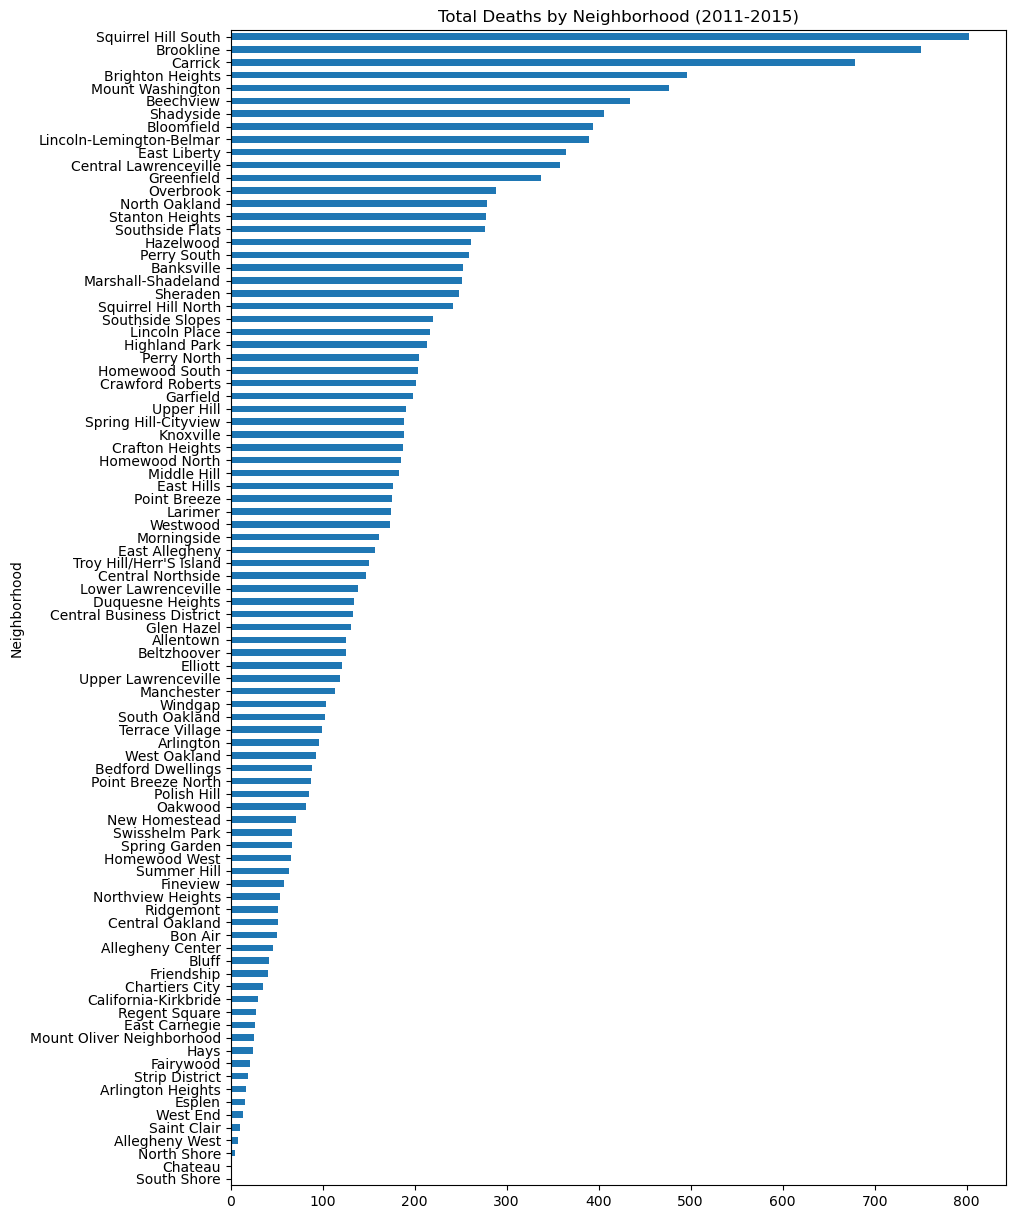

In [5]:
# Visualize the results in a bar graph
graph = data.plot.barh(x = "Neighborhood", y = "Total Deaths", title = "Total Deaths by Neighborhood (2011-2015)", figsize = (10, 15), legend = False)

In [6]:
# Make a new Series based on the order of the sorted data for Total Deaths
# Make a copy to avoid changing the reference later on
death_scores = pd.Series(data.copy().index + 1, index = data["Neighborhood"].copy())
print("Ordering by Total Deaths")

for key, value in death_scores.items():
    if value > 10:
        continue
    print(f"{value}: {key}")
print("...")
print(f"{death_scores.iloc[-1]}: {death_scores.index[-1]}")
# The order is the same as the reverse order of the bar graph above

Ordering by Total Deaths
1: South Shore
2: Chateau
3: North Shore
4: Allegheny West
5: Saint Clair
6: West End
7: Esplen
8: Arlington Heights
9: Strip District
10: Fairywood
...
90: Squirrel Hill South


---

## Median Age at Death

With total deaths score found, we can now go to the median age at death score. As said previously, *South Shore* and *Chateau* will be the top 2 as they had the lowest amount of total deaths anyways. For the rest, however, the median age at death is also important and might change up the submetric values.

Because the DataFrame already has the top 2 for median age at death already in the correct ordering, we can slice the DataFrame and only sort the remaining rows by the median age at death, this time in descending order because a higher median age at death is considered better as that means more life can be lived.

In [7]:
# Slice the list then sort that portion, skipping the first 2 rows
data[2:] = data[2:].sort_values("Total Median Age at Death", ascending = False)

# Print out the new first 10 rows
data.head(10)

,Neighborhood,Total Deaths,Total Median Age at Death
0,South Shore,0.0,0.0
1,Chateau,2.0,NaN
2,Squirrel Hill South,802.0,85.9
3,North Oakland,279.0,85.6
4,Banksville,253.0,85.5
5,Point Breeze,175.0,85.1
6,Squirrel Hill North,242.0,85.0
7,Central Oakland,52.0,84.0
8,New Homestead,71.0,83.4
9,Swisshelm Park,67.0,83.1


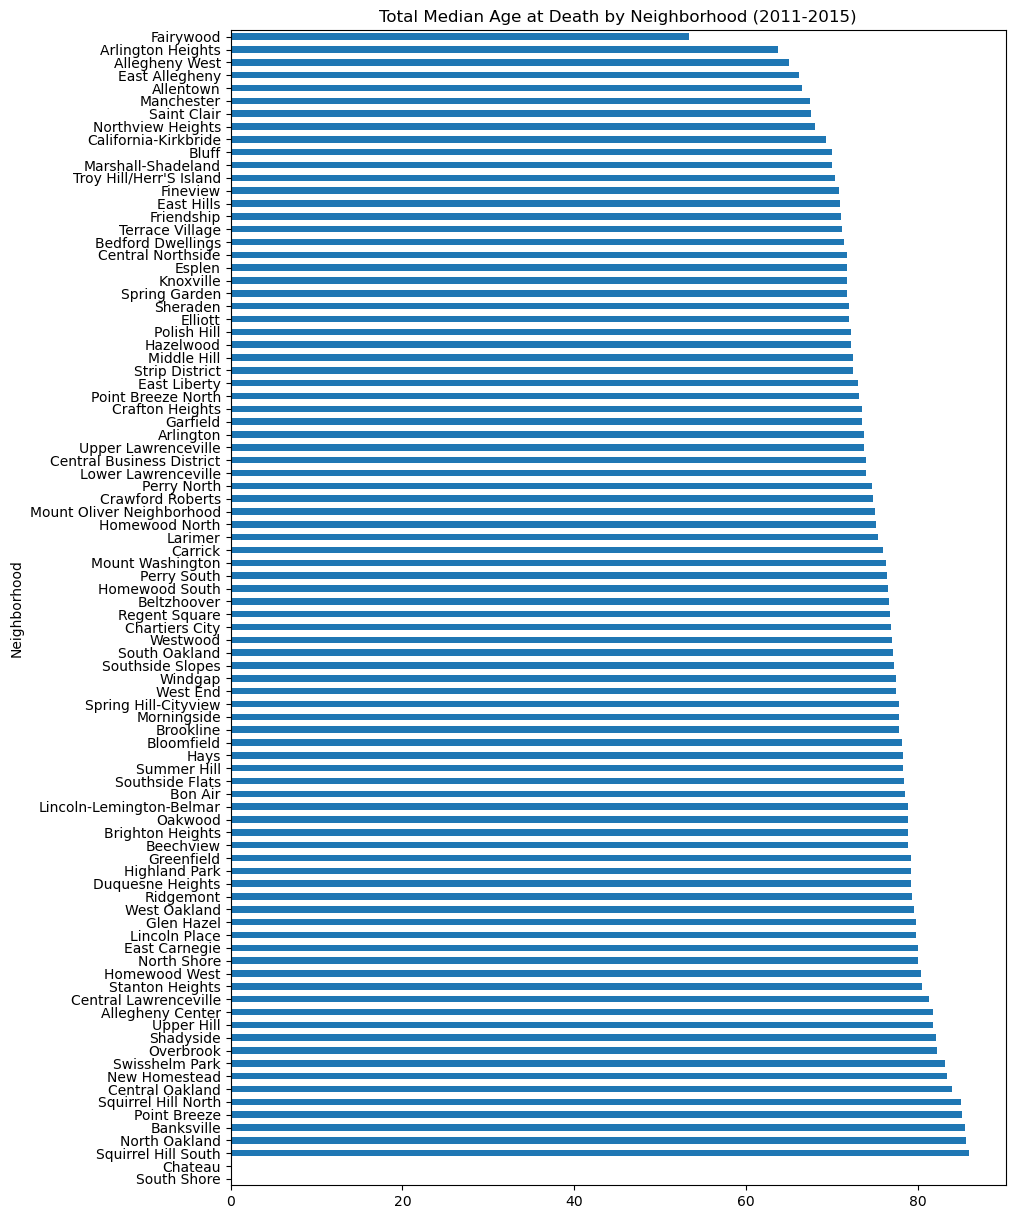

In [8]:
# Visualize the results in a bar graph
graph = data.plot.barh(x = "Neighborhood", y = "Total Median Age at Death", title = "Total Median Age at Death by Neighborhood (2011-2015)", figsize = (10, 15), legend = False)

In [9]:
# Make a new Series based on the order of the sorted data for Total Median Age at Death
# Again, use copy() to avoid changing the reference (though not as necessary here as before)
median_scores = pd.Series(data.copy().index + 1, index = data["Neighborhood"].copy())
print("Ordering by Total Median Age at Death")
for key, value in median_scores.items():
    if value > 10:
        continue
    print(f"{value}: {key}")
print("...")
print(f"{median_scores.iloc[-1]}: {median_scores.index[-1]}")
# The order is the same as the reverse order of the bar graph above

Ordering by Total Median Age at Death
1: South Shore
2: Chateau
3: Squirrel Hill South
4: North Oakland
5: Banksville
6: Point Breeze
7: Squirrel Hill North
8: Central Oakland
9: New Homestead
10: Swisshelm Park
...
90: Fairywood


---

## Submetric

Now that both scores are found, we can combine them to find the final submetric. To reiterate, the scores from the data will be summed and then there will be a final order. This final order will then be used as the submetric for this dataset.

In [10]:
# Make a new Series that holds the submetric score for each neighborhood by adding together the scores of each individual data point
submetric = death_scores + median_scores
submetric = submetric.sort_values()

# Update the submetric to use the new order. This accesses every value and sets it to be its position using 1-indexing
submetric[:] = range(1, len(submetric) + 1)

# No need to display the results here as there is a graph for that
# # Display the results
# print("Submetric scores for each neighborhood")
# for key, value in submetric.items():
#     print(f"{key}: {value}")

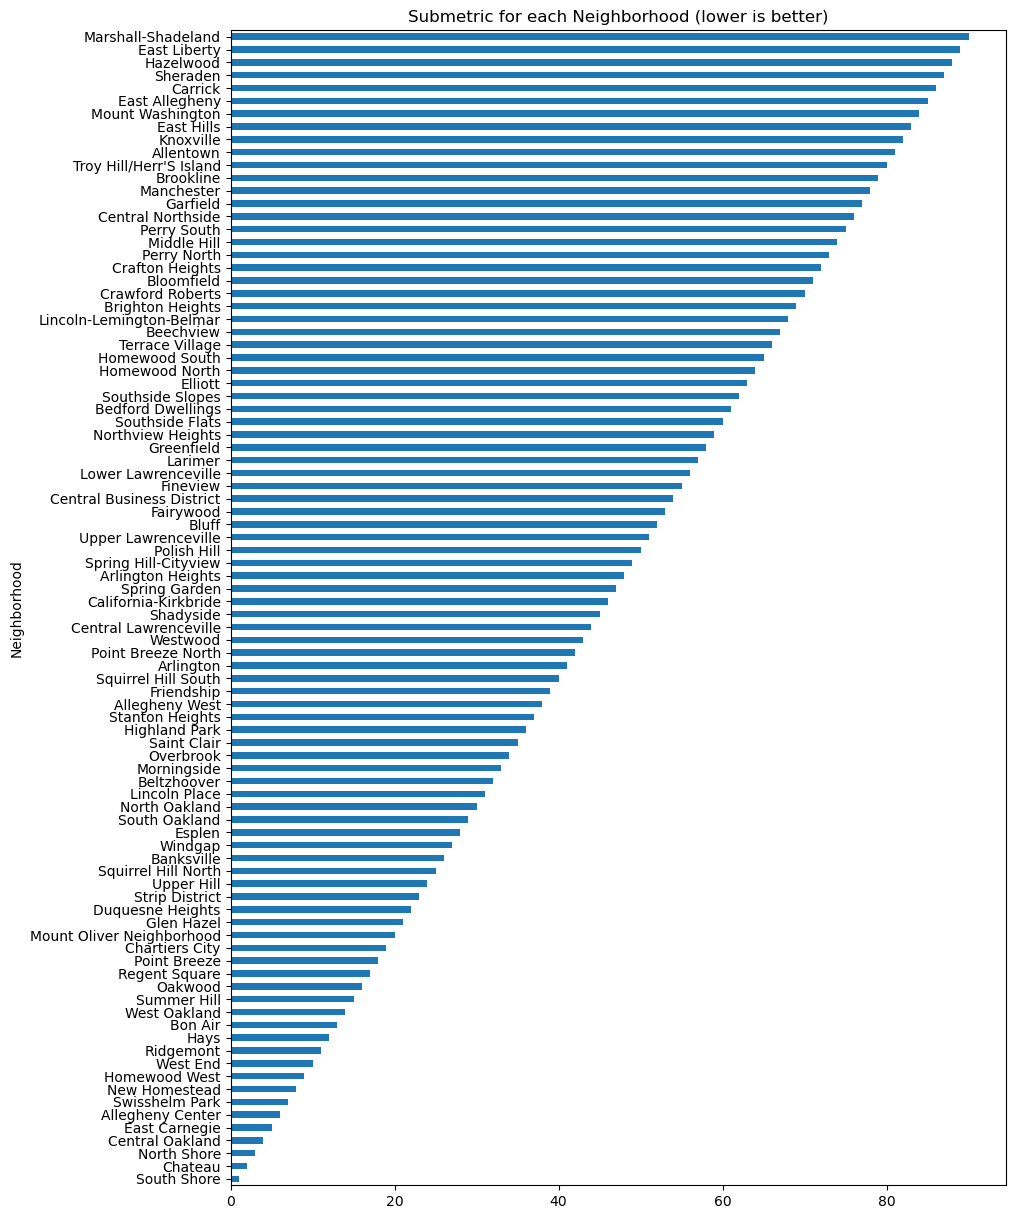

In [11]:
graph = submetric.plot.barh(title = "Submetric for each Neighborhood (lower is better)", figsize = (10, 15))

---

# Conclusion

In conclusion, from this dataset, we determined that the submetric should be the ranking of the neighborhoods using the total deaths and median age at death as the data points. To get the submetric, the order of the neighborhoods in the sorted list of the sum of scores from the sorted data points was used (which sounds really complicated, but hopefully is explained well previously). This way of getting the submetric doesn't take into account any of the values of the data points themsevles, only their relative ordering between all the neighborhoods. To correct the missing or inacccurate median at age of death data, the total deaths was used to give the position. This resulted in both *South Shore* and *Chateau* to be placed into first and second of that data point's ranking. This was seen as a fair compromise for their low total deaths, which was then seen as more important (so as to not punish these neighborhoods, which is explained prior). From this, it makes sense that the top 2 are *South Shore* and *Chateau* using this submetric. Next, in 3rd place was *North Shore*, which came in 3rd for total deaths, only having 5, and coming in 18th place for median age at death with 80yrs old. While *Squirrel Hill South* came in 3rd place for the median age at death, it came in last place for number of deaths, having about 800 deaths looking at the bar graph. The interpretation of this data likely means that many older people are dying in *Squirrel Hill South*, maybe due to having a larger number of older people to explain this. Of course, this analysis of the dataset doesn't include the population demographics, which could be seen as the next logical step to understanding this data better. But, for the purposes of the submetric, we conclude that *South Shore* is the best neighborhood according to this submetric, which takes into account the total deaths and median age at death for each neighborhood.

---

### Bonus

Visualizations and summary statistics to better understand the data for the entirety of Pittsburgh (obviously has nothing to do with ranking the neighborhoods):

,Total Deaths,Total Median Age at Death
count,90.000000,89.000000
mean,171.211111,74.848315
std,158.504988,9.736227
min,0.000000,0.000000
25%,55.000000,72.000000
50%,133.500000,76.500000
75%,219.250000,79.200000
max,802.000000,85.900000


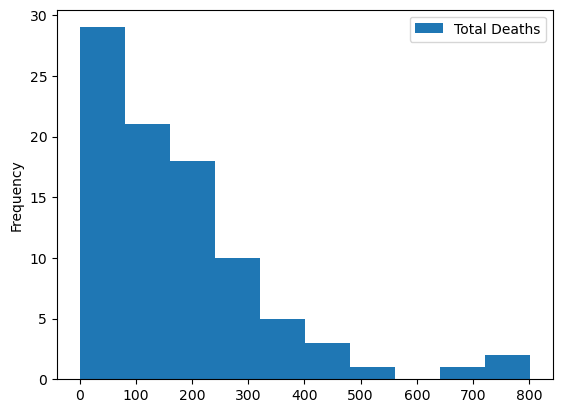

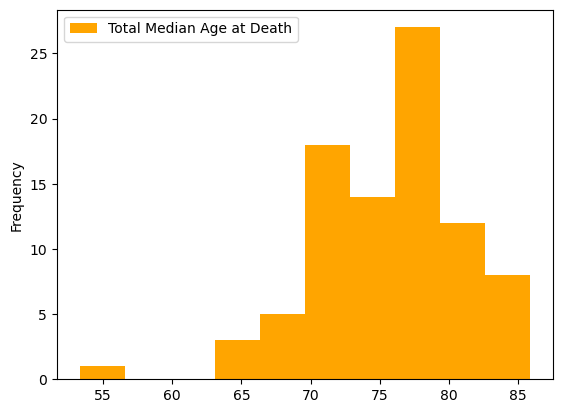

In [12]:
graph = data.plot.hist(x = "Neighborhood", y = "Total Deaths")
graph = data[2:].plot.hist(x = "Neighborhood", y = "Total Median Age at Death", color = "orange")
data.describe()

The first histogram shows the frequency of total deaths within a range. Clearly, the data is right-skewed with a median of 133.5 deaths and a mean of about 171.211111 deaths.

The second histogram shows the frequency of median age at death within a range. The data is slightly left-skewed with a median of 76.5yrs and a mean of about 74.848315yrs.